# Taller 2 — Análisis de portafolio (datos investing.com)


## Cómo correr este notebook en Google Colab

### 1. Abrir el notebook

Ve a [colab.research.google.com](https://colab.research.google.com) → **Archivo → Subir notebook** y sube este archivo `.ipynb`.

### 2. Subir los archivos de datos

Este notebook lee los CSVs de la carpeta `activos/`. Súbelos usando el panel de archivos (ícono de carpeta en el panel izquierdo) o con este snippet al inicio de la sesión:

```python
from google.colab import files
import zipfile, os

uploaded = files.upload()          # sube activos.zip con todos los CSVs adentro
with zipfile.ZipFile("activos.zip") as z:
    z.extractall(".")              # extrae → crea carpeta activos/
```

O puedes subir los archivos uno a uno directamente al panel de archivos dentro de una carpeta llamada `activos`.

### 3. Subir el formulario (Punto 8)

El Punto 8 requiere `formulario_respuesta.xlsx`. Súbelo al panel de archivos o con:

```python
from google.colab import files
files.upload()   # selecciona formulario_respuesta.xlsx
```

### 4. Instalar dependencias

Corre la celda `%pip install ...`. Colab ya tiene `numpy`, `pandas` y `matplotlib` pero necesita `openpyxl`.

### 5. Correr las celdas en orden

Corre todas las celdas de arriba hacia abajo con **Runtime → Run all**.

> ⚠️ Los archivos subidos **solo existen mientras la sesión esté activa**. Si el runtime se reinicia, debes subir los archivos nuevamente antes de correr el notebook.


In [190]:
%pip install -q matplotlib numpy pandas openpyxl

/Users/david/personal-repos/python-sandbox/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [191]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# === Configuración ===========================================================
RF_ANUAL = 0.0425  # Tasa libre de riesgo anual fija (4.25%)
TRADING_PERIODS = 52  # Datos semanales

activos_path = "activos"
formulario_path = "formulario_respuesta.xlsx"
# =============================================================================

## Carga de datos desde carpeta `activos`


In [ ]:
TICKER_MAP = {
    "Southern": "SO",
    "Verizon": "VZ",
    "P&G": "PG",
    "Merck": "MRK",
    "J&J": "JNJ",
    "Duke Energy": "DUK",
    "Coca-Cola": "KO",
    "Chevron": "CVX",
    "AT&T": "T",
    "Walmart": "WMT",
}


def load_investing_csv(filepath, name):
    df = pd.read_csv(filepath)
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
    df = df.set_index("Date").sort_index()
    # "Change %" viene como "-0.99%" → convertir a decimal (-0.0099)
    ret = (
        pd.to_numeric(df["Change %"].str.replace("%", "", regex=False), errors="coerce")
        / 100
    )
    ret.name = name
    return ret


# Cargar retornos de acciones
series = []
for fname in glob.glob(os.path.join(activos_path, "*.csv")):
    basename = os.path.basename(fname)
    if "IVV" in basename:
        continue
    ticker = next((t for key, t in TICKER_MAP.items() if key in basename), None)
    if ticker:
        series.append(load_investing_csv(fname, ticker))

ret = pd.concat(series, axis=1).sort_index()
ret = ret.loc["2015-01-01":"2024-12-31"]
ret = ret[ret.index.year != 2020].dropna(how="any")
ret = ret[sorted(ret.columns)]

# Cargar retornos de IVV
ivv_file = glob.glob(os.path.join(activos_path, "IVV*.csv"))[0]
ret_ivv = load_investing_csv(ivv_file, "IVV")
ret_ivv = ret_ivv.loc["2015-01-01":"2024-12-31"]
ret_ivv = ret_ivv[ret_ivv.index.year != 2020].dropna()

tickers = ret.columns.tolist()
n_activos = len(tickers)

print(f"Observaciones: {len(ret):,}")
print(f"Activos ({n_activos}): {tickers}")
print("Rango de fechas:", ret.index.min().date(), "->", ret.index.max().date())
display(ret.head())

Observaciones: 470
Activos (10): ['CVX', 'DUK', 'JNJ', 'KO', 'MRK', 'PG', 'SO', 'T', 'VZ', 'WMT']
Rango de fechas: 2015-01-04 -> 2024-12-29


,CVX,DUK,JNJ,KO,MRK,PG,SO,T,VZ,WMT
Date,,,,,,,,,,
2015-01-04,-0.038800,0.010500,0.004000,0.021100,0.093900,-0.002100,0.006700,-0.014100,-0.004300,0.040200
2015-01-11,-0.028600,0.028500,-0.008600,-0.011600,0.007500,0.011100,0.033200,0.011900,0.026300,-0.028900
2015-01-18,0.016500,0.015700,-0.017700,0.018300,-0.008500,-0.012800,0.017100,-0.012500,-0.017500,0.020100
2015-01-25,-0.040400,-0.017800,-0.020200,-0.049400,-0.035400,-0.064300,-0.028900,-0.013500,-0.030500,-0.039700
2015-02-01,0.069100,-0.046200,0.009600,0.006800,-0.024700,0.015700,-0.050300,0.059100,0.079200,0.027500


## Punto 2 — Retornos, desviación estándar, Sharpe y correlación

> Retornos simples semanales anualizados con $T = 52$:

> - $\mu_{anual} = \mu_{semanal} \times 52$

> - $\sigma_{anual} = \sigma_{semanal} \times \sqrt{52}$

> Sharpe: $S_i = \dfrac{\mu_i - r_f}{\sigma_i}$, con $r_f = 4.25\%$.


In [193]:
rf_anual = RF_ANUAL

mu_anual = ret.mean() * TRADING_PERIODS
sigma_anual = ret.std() * np.sqrt(TRADING_PERIODS)
sharpe_activos = (mu_anual - rf_anual) / sigma_anual

tabla_resumen = pd.DataFrame(
    {
        "Retorno anual esperado": mu_anual,
        "Volatilidad anual": sigma_anual,
        "Sharpe anual": sharpe_activos,
    }
).sort_values("Sharpe anual", ascending=False)

corr = ret.corr()

print(f"rf anual usado: {rf_anual:.4%}")
display(tabla_resumen)
display(corr)

rf anual usado: 4.2500%


,Retorno anual esperado,Volatilidad anual,Sharpe anual
WMT,0.125176,0.197150,0.419357
MRK,0.097904,0.198483,0.279137
CVX,0.098866,0.239771,0.235084
SO,0.072258,0.165430,0.179882
PG,0.065597,0.160742,0.143693
KO,0.053394,0.150900,0.072194
T,0.041102,0.203365,-0.006874
DUK,0.039697,0.165392,-0.016947
JNJ,0.037916,0.154108,-0.029747
VZ,0.005134,0.195134,-0.191491


,CVX,DUK,JNJ,KO,MRK,PG,SO,T,VZ,WMT
CVX,1.000000,0.113273,0.259543,0.202567,0.212040,0.157453,0.134031,0.309611,0.282134,0.158698
DUK,0.113273,1.000000,0.378552,0.471907,0.194640,0.419694,0.804716,0.299529,0.393469,0.238587
JNJ,0.259543,0.378552,1.000000,0.444289,0.452176,0.455427,0.414592,0.316085,0.352896,0.299303
KO,0.202567,0.471907,0.444289,1.000000,0.329710,0.599363,0.460201,0.371299,0.391376,0.364160
MRK,0.212040,0.194640,0.452176,0.329710,1.000000,0.274437,0.155198,0.277444,0.274318,0.235558
PG,0.157453,0.419694,0.455427,0.599363,0.274437,1.000000,0.407763,0.338358,0.369985,0.392051
SO,0.134031,0.804716,0.414592,0.460201,0.155198,0.407763,1.000000,0.298694,0.377100,0.228427
T,0.309611,0.299529,0.316085,0.371299,0.277444,0.338358,0.298694,1.000000,0.615327,0.195086
VZ,0.282134,0.393469,0.352896,0.391376,0.274318,0.369985,0.377100,0.615327,1.000000,0.249406
WMT,0.158698,0.238587,0.299303,0.364160,0.235558,0.392051,0.228427,0.195086,0.249406,1.000000


## Punto 3 — Matriz varianza-covarianza anualizada

> $\Sigma = \text{Cov}(r_{semanal}) \times 52$


In [194]:
cov_anual = ret.cov() * TRADING_PERIODS
display(cov_anual)

,CVX,DUK,JNJ,KO,MRK,PG,SO,T,VZ,WMT
CVX,0.057490,0.004492,0.009590,0.007329,0.010091,0.006068,0.005316,0.015097,0.013200,0.007502
DUK,0.004492,0.027354,0.009649,0.011778,0.006390,0.011158,0.022018,0.010075,0.012699,0.007780
JNJ,0.009590,0.009649,0.023749,0.010332,0.013831,0.011282,0.010570,0.009906,0.010612,0.009094
KO,0.007329,0.011778,0.010332,0.022771,0.009875,0.014538,0.011488,0.011394,0.011524,0.010834
MRK,0.010091,0.006390,0.013831,0.009875,0.039395,0.008756,0.005096,0.011199,0.010625,0.009218
PG,0.006068,0.011158,0.011282,0.014538,0.008756,0.025838,0.010843,0.011061,0.011605,0.012424
SO,0.005316,0.022018,0.010570,0.011488,0.005096,0.010843,0.027367,0.010049,0.012173,0.007450
T,0.015097,0.010075,0.009906,0.011394,0.011199,0.011061,0.010049,0.041357,0.024418,0.007822
VZ,0.013200,0.012699,0.010612,0.011524,0.010625,0.011605,0.012173,0.024418,0.038077,0.009595
WMT,0.007502,0.007780,0.009094,0.010834,0.009218,0.012424,0.007450,0.007822,0.009595,0.038868


## Punto 4 — Portafolio equally weighted

> $w_i = 1/10$, $E[r_p] = w^T\mu$, $\sigma_p = \sqrt{w^T\Sigma w}$


In [195]:
w_eq = np.repeat(1.0 / n_activos, n_activos)
mu_vec = mu_anual.to_numpy(dtype=float)
cov_mat = cov_anual.to_numpy(dtype=float)

ret_eq = w_eq @ mu_vec
vol_eq = np.sqrt(w_eq @ cov_mat @ w_eq)
sharpe_eq = (ret_eq - rf_anual) / vol_eq

comparacion_vol = pd.DataFrame({"Vol anual activo": sigma_anual}).sort_values(
    "Vol anual activo"
)

print(f"Retorno esperado anual (equally weighted): {ret_eq:.4%}")
print(f"Volatilidad anual (equally weighted): {vol_eq:.4%}")
print(f"Sharpe anual (equally weighted): {sharpe_eq:.4f}")
display(comparacion_vol)

Retorno esperado anual (equally weighted): 6.3704%
Volatilidad anual (equally weighted): 11.3928%
Sharpe anual (equally weighted): 0.1861


,Vol anual activo
KO,0.150900
JNJ,0.154108
PG,0.160742
DUK,0.165392
SO,0.165430
VZ,0.195134
WMT,0.197150
MRK,0.198483
T,0.203365
CVX,0.239771


## Punto 5 — Portafolio eficiente óptimo (máximo Sharpe) con simulación

> Se simulan 100,000 portafolios aleatorios y se identifica el de mayor Sharpe.


In [196]:
np.random.seed(42)
N_SIM = 100_000

weights = np.random.dirichlet(alpha=np.ones(n_activos), size=N_SIM)

rets_sim = weights @ mu_vec
vars_sim = np.einsum("ij,jk,ik->i", weights, cov_mat, weights)
vols_sim = np.sqrt(vars_sim)
sharpes_sim = (rets_sim - rf_anual) / vols_sim

idx_max_sharpe = np.argmax(sharpes_sim)
w_opt = weights[idx_max_sharpe]

pesos_optimos = (
    pd.DataFrame({"Ticker": tickers, "Peso óptimo": w_opt})
    .sort_values("Peso óptimo", ascending=False)
    .reset_index(drop=True)
)

display(pesos_optimos)
print(f"Sharpe máximo simulado: {sharpes_sim[idx_max_sharpe]:.4f}")

,Ticker,Peso óptimo
0,WMT,0.671986
1,MRK,0.110135
2,CVX,0.086926
3,SO,0.041311
4,JNJ,0.023334
5,KO,0.021224
6,PG,0.019524
7,T,0.013015
8,VZ,0.007194
9,DUK,0.005351


Sharpe máximo simulado: 0.4468


## Punto 6 — Retorno y desviación del portafolio óptimo + comparación con IVV


In [197]:
ret_opt = rets_sim[idx_max_sharpe]
vol_opt = vols_sim[idx_max_sharpe]
sharpe_opt = sharpes_sim[idx_max_sharpe]

print(f"E[r_p] anual (portafolio óptimo): {ret_opt:.4%}")
print(f"\u03c3_p anual (portafolio óptimo): {vol_opt:.4%}")
print(f"Sharpe anual (portafolio óptimo): {sharpe_opt:.4f}")

mu_ivv_anual = ret_ivv.mean() * TRADING_PERIODS
sigma_ivv_anual = ret_ivv.std() * np.sqrt(TRADING_PERIODS)
sharpe_ivv = (mu_ivv_anual - RF_ANUAL) / sigma_ivv_anual

comparacion_p6 = pd.DataFrame(
    {
        "Retorno anual esperado": [ret_opt, mu_ivv_anual],
        "Volatilidad anual": [vol_opt, sigma_ivv_anual],
        "Sharpe anual": [sharpe_opt, sharpe_ivv],
    },
    index=["Portafolio óptimo", "IVV"],
)

display(comparacion_p6)

E[r_p] anual (portafolio óptimo): 11.0561%
σ_p anual (portafolio óptimo): 15.2332%
Sharpe anual (portafolio óptimo): 0.4468


,Retorno anual esperado,Volatilidad anual,Sharpe anual
Portafolio óptimo,0.110561,0.152332,0.446797
IVV,0.111125,0.143762,0.477351


## Punto 7 — Frontera eficiente y CAL óptima

> $$E[r] = r_f + \left(\frac{E[r_p]-r_f}{\sigma_p}\right)\sigma$$


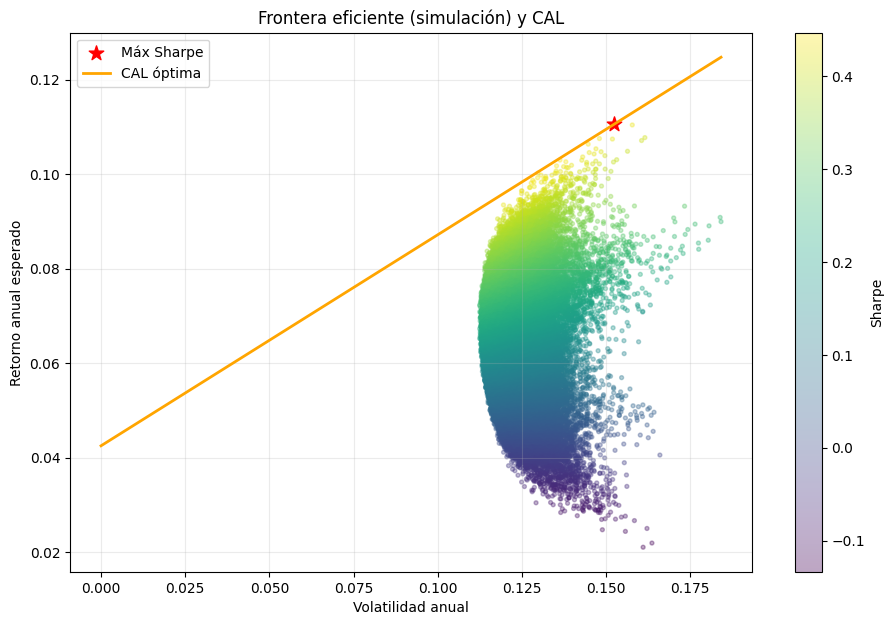

In [198]:
plt.figure(figsize=(11, 7))
sc = plt.scatter(vols_sim, rets_sim, c=sharpes_sim, cmap="viridis", alpha=0.35, s=8)
plt.colorbar(sc, label="Sharpe")

plt.scatter(vol_opt, ret_opt, color="red", s=120, marker="*", label="Máx Sharpe")

sigma_linea = np.linspace(0, vols_sim.max(), 200)
cal_linea = rf_anual + sharpe_opt * sigma_linea
plt.plot(sigma_linea, cal_linea, color="orange", linewidth=2.0, label="CAL óptima")

plt.xlabel("Volatilidad anual")
plt.ylabel("Retorno anual esperado")
plt.title("Frontera eficiente (simulación) y CAL")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Punto 8 — Portafolio completo óptimo para cada nivel de aversión ($A$)

> $$y^* = \frac{E[r_p]-r_f}{A\sigma_p^2}$$


In [199]:
encuesta = pd.read_excel(formulario_path)

A_series = (
    pd.to_numeric(encuesta.iloc[:, 31], errors="coerce")
    .dropna()
    .round()
    .astype(int)
    .reset_index(drop=True)
)

df_A = pd.DataFrame(
    {
        "Entrevistado": [f"Persona {i + 1}" for i in range(len(A_series))],
        "A": A_series,
    }
)

if df_A.empty:
    print("No se encontraron valores numéricos de A en la columna AF del formulario.")
else:
    prima_riesgo_opt = ret_opt - rf_anual
    df_A["y_estrella"] = prima_riesgo_opt / (df_A["A"] * (vol_opt**2))
    df_A["E_rT"] = rf_anual + df_A["y_estrella"] * prima_riesgo_opt
    df_A["sigma_T"] = df_A["y_estrella"] * vol_opt
    df_A["Peso_riesgoso"] = df_A["y_estrella"]
    df_A["Peso_libre_riesgo"] = 1 - df_A["y_estrella"]

    display(df_A)

,Entrevistado,A,y_estrella,E_rT,sigma_T,Peso_riesgoso,Peso_libre_riesgo
0,Persona 1,6,0.488843,0.075771,0.074466,0.488843,0.511157
1,Persona 2,6,0.488843,0.075771,0.074466,0.488843,0.511157
2,Persona 3,4,0.733264,0.092407,0.111699,0.733264,0.266736
3,Persona 4,3,0.977685,0.109043,0.148932,0.977685,0.022315
4,Persona 5,4,0.733264,0.092407,0.111699,0.733264,0.266736
5,Persona 6,6,0.488843,0.075771,0.074466,0.488843,0.511157


## Punto 9 — Betas CAPM por activo (vs IVV)

> $$\beta_i = \frac{\operatorname{Cov}(r_i, r_m)}{\operatorname{Var}(r_m)}$$


In [200]:
ret_mercado = ret_ivv.rename("IVV")
ret_alineados = ret.join(ret_mercado, how="inner").dropna()

var_mercado = ret_alineados["IVV"].var()
cov_con_mercado = pd.Series(
    {t: ret_alineados[t].cov(ret_alineados["IVV"]) for t in tickers}
)
betas_capm = (cov_con_mercado / var_mercado).sort_values(ascending=False)

tabla_betas = pd.DataFrame({"Beta CAPM (vs IVV)": betas_capm})
print(f"Varianza semanal del mercado (IVV): {var_mercado:.8f}")
display(tabla_betas)

Varianza semanal del mercado (IVV): 0.00039745


,Beta CAPM (vs IVV)
CVX,0.756774
WMT,0.633047
PG,0.525187
T,0.517787
KO,0.508028
JNJ,0.491841
VZ,0.459825
MRK,0.448580
SO,0.337666
DUK,0.284397
